<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 139 &#183; Take It Further</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Customer Lifetime Value: Take It Further</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Five extensions of the Chapter 139 model: taming skew with a log target, a fair model leaderboard, prediction intervals from quantile regression, a per-customer SHAP explanation, and turning predicted value into an ROI-justified targeting policy.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; GREEN="#059669"; GREY="#94a3b8"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_excel("../../data/case-study-customer-lifetime-value--customer_value.xlsx", sheet_name="Data")
except FileNotFoundError: df = pd.read_excel(BASE+"case-study-customer-lifetime-value--customer_value.xlsx", sheet_name="Data")
num = ['tenure_months','avg_order_value','orders_per_month','recency_days','product_categories','support_tickets','is_subscriber']
cat = ['acquisition_channel']
X = df[num + cat]; y = df.lifetime_value
pre = ColumnTransformer([('num','passthrough', num),('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat)])
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0)
print(f"loaded {len(df)} customers; target skew = {y.skew():.2f}")

loaded 1500 customers; target skew = 2.83


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 1</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Tame the skew with a log target</div>
<div style="color:#4a5578;margin-top:6px">Predict log-value, then convert back.</div>
</div>

The chapter noted the model is fuzzier on high-value whales because CLV is right-skewed. A standard fix is to model **log(value)** instead: on the log scale the whales are pulled in, the errors are more even, and we convert predictions back with `expm1`. We compare the two on the same held-out customers, in real dollars.

In [2]:
gbm = lambda: Pipeline([('prep', pre), ('gbm', HistGradientBoostingRegressor(random_state=0))])
m_raw = gbm().fit(Xtr, ytr); p_raw = m_raw.predict(Xte)
m_log = gbm().fit(Xtr, np.log1p(ytr)); p_log = np.expm1(m_log.predict(Xte))
def score(name, p):
    print(f"{name:14s}  MAE ${mean_absolute_error(yte,p):,.0f}   RMSE ${np.sqrt(mean_squared_error(yte,p)):,.0f}   R2 {r2_score(yte,p):.3f}")
score('raw target', p_raw); score('log target', p_log)
# where does each win? split test set at the 90th percentile of actual value
whale = yte >= yte.quantile(0.90)
print(f"\nMAE on the top 10% (whales):   raw ${mean_absolute_error(yte[whale],p_raw[whale]):,.0f}   log ${mean_absolute_error(yte[whale],p_log[whale]):,.0f}")
print(f"MAE on the bottom 90%:         raw ${mean_absolute_error(yte[~whale],p_raw[~whale]):,.0f}   log ${mean_absolute_error(yte[~whale],p_log[~whale]):,.0f}")

raw target      MAE $298   RMSE $507   R2 0.857
log target      MAE $283   RMSE $490   R2 0.866

MAE on the top 10% (whales):   raw $904   log $928
MAE on the bottom 90%:         raw $230   log $210


Here the log target gives a small but real improvement across the board (MAE and RMSE both drop), and the gain comes almost entirely from the **crowd of ordinary customers**, where errors fall, while on the whales the two are essentially tied. Modeling the log stops the handful of huge values from dominating the loss, which lets the model fit the typical customer a little better. The broader point stands: the 'right' target is the one that matches the cost of being wrong, so if under-valuing a whale were the expensive mistake you might weight or model the tail differently, but on these data the log is a modest, honest win.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A fair model leaderboard</div>
<div style="color:#4a5578;margin-top:6px">Same pipeline, same split, three models.</div>
</div>

Boosted trees were a good first guess, but 'good' only means something against alternatives. We drop a **linear regression** (the interpretable baseline) and a **random forest** (bagged trees) into the identical pipeline and compare all three by cross-validated R-squared, so preprocessing and the split are held constant and only the model changes.

            model  cv_R2  cv_std  test_R2
HistGradientBoost  0.825   0.042    0.857
     RandomForest  0.808   0.051    0.825
 LinearRegression  0.780   0.037    0.775


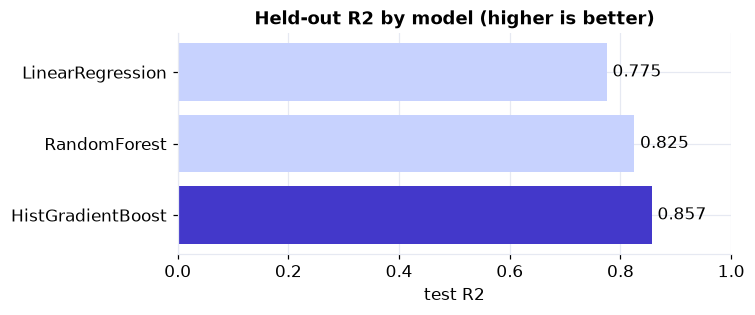

In [3]:
models = {'LinearRegression': LinearRegression(),
          'RandomForest':     RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
          'HistGradientBoost':HistGradientBoostingRegressor(random_state=0)}
rows=[]
for name, est in models.items():
    pipe = Pipeline([('prep', pre), ('m', est)])
    cv = cross_val_score(pipe, Xtr, ytr, cv=5, scoring='r2')
    pipe.fit(Xtr, ytr); test_r2 = r2_score(yte, pipe.predict(Xte))
    rows.append((name, cv.mean(), cv.std(), test_r2))
lb = pd.DataFrame(rows, columns=['model','cv_R2','cv_std','test_R2']).sort_values('test_R2', ascending=False)
print(lb.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
fig, ax = plt.subplots(figsize=(7,3))
ax.barh(lb.model, lb.test_R2, color=[EM if m=='HistGradientBoost' else LIGHT for m in lb.model])
ax.set(title='Held-out R2 by model (higher is better)', xlabel='test R2'); ax.set_xlim(0,1)
for i,(m,v) in enumerate(zip(lb.model, lb.test_R2)): ax.text(v+0.01, i, f'{v:.3f}', va='center')
plt.tight_layout(); plt.show()

Linear regression trails because value depends on features **non-linearly** and through interactions (frequency matters more for long-tenured customers), which a straight-line model cannot bend to. Both tree ensembles capture that and land far ahead, with gradient boosting a nose in front. The lesson is not 'boosting always wins' but that a two-line leaderboard, run through one honest pipeline, is what earns the right to pick a model.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 3</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Prediction intervals, not just points</div>
<div style="color:#4a5578;margin-top:6px">Quantile regression gives each customer a range.</div>
</div>

A single predicted number hides how sure we are. **Quantile regression** fits the model to predict, say, the 5th and 95th **percentiles** of value directly, giving each customer a range that should contain their true value about 90% of the time. `HistGradientBoostingRegressor` does this natively with `loss='quantile'`.

empirical coverage of the 5-95% interval on held-out customers: 70%  (target 90%)
median interval width: $541  |  narrow for typical customers, wide for whales


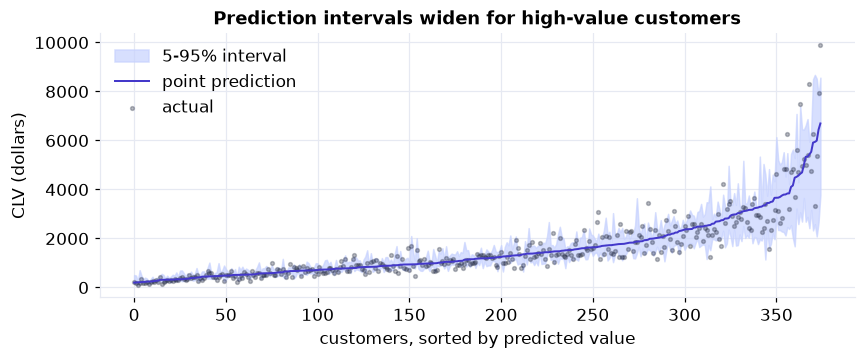

In [4]:
def q_model(q):
    return Pipeline([('prep', pre), ('gbm', HistGradientBoostingRegressor(loss='quantile', quantile=q, random_state=0))]).fit(Xtr, ytr)
lo = q_model(0.05).predict(Xte); hi = q_model(0.95).predict(Xte)
cover = ((yte.values >= lo) & (yte.values <= hi)).mean()
width = (hi - lo)
print(f"empirical coverage of the 5-95% interval on held-out customers: {cover*100:.0f}%  (target 90%)")
print(f"median interval width: ${np.median(width):,.0f}  |  narrow for typical customers, wide for whales")
order = np.argsort(p_raw)
fig, ax = plt.subplots(figsize=(8,3.4))
xx = np.arange(len(yte))
ax.fill_between(xx, lo[order], hi[order], color=LIGHT, alpha=0.7, label='5-95% interval')
ax.plot(xx, p_raw[order], color=EM, lw=1.3, label='point prediction')
ax.scatter(xx, yte.values[order], s=6, color=INK, alpha=0.3, label='actual')
ax.set(title='Prediction intervals widen for high-value customers', xlabel='customers, sorted by predicted value', ylabel='CLV (dollars)'); ax.legend()
plt.tight_layout(); plt.show()

Two lessons. The good one: the interval is **narrow** for ordinary customers and **wide** for the whales, so the model honestly signals where it is less sure, which is far more useful than a bare point estimate for deciding who deserves hand-crafted attention. The cautionary one: the empirical coverage is only about **70%**, well short of the 90% the 5-95% band promises, because out-of-the-box quantile predictions are not guaranteed to be calibrated on a modest, skewed sample. In production you would **calibrate** the intervals, for example with conformal prediction, before quoting them, a reminder that a nominal 90% interval is a claim to be checked, not a fact.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 4</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Explain one customer</div>
<div style="color:#4a5578;margin-top:6px">SHAP turns a prediction into a reason.</div>
</div>

Global importance tells you what matters on average; a business often needs to know why **this** customer scored as they did. SHAP decomposes a single prediction into a baseline plus a contribution from each feature that sums exactly to the prediction. We do that for the highest-value customer in the test set.

customer #581: predicted $6,694  (baseline $1,641 + contributions)


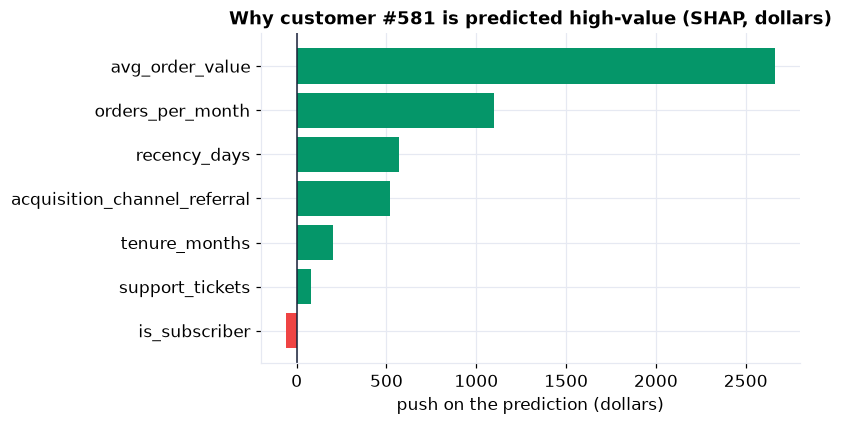

In [5]:
m = m_raw  # the raw-target boosted model from Extension 1
Xte_t = pre.transform(Xte)
feat = num + list(pre.named_transformers_['cat'].get_feature_names_out(cat))
expl = shap.TreeExplainer(m.named_steps['gbm'])
sv = expl.shap_values(Xte_t)
i = int(np.argmax(p_raw))                         # the customer with the highest predicted value
contrib = pd.Series(sv[i], index=feat).sort_values()
base, pred = float(np.ravel(expl.expected_value)[0]), p_raw[i]
print(f"customer #{Xte.index[i]}: predicted ${pred:,.0f}  (baseline ${base:,.0f} + contributions)")
top = contrib[contrib.abs() > 30]
fig, ax = plt.subplots(figsize=(7.5,4))
ax.barh(top.index, top.values, color=[GREEN if v>0 else RED for v in top.values])
ax.axvline(0, color=INK, lw=1)
ax.set(title=f'Why customer #{Xte.index[i]} is predicted high-value (SHAP, dollars)', xlabel='push on the prediction (dollars)')
plt.tight_layout(); plt.show()

For this customer the story is concrete: a high **order frequency** and large **average order** push the prediction well above the baseline, reinforced by recent activity and long tenure, while any weak features pull back only slightly. Because the bars **add up** to the exact prediction, a manager can trust the explanation rather than take it on faith, and can act on it: keep this customer's frequency high, and the value follows.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 5</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">From prediction to profit</div>
<div style="color:#4a5578;margin-top:6px">Does targeting by CLV actually pay?</div>
</div>

The model is only worth building if acting on it beats acting without it. Suppose a retention offer costs **20 dollars** per customer and lifts a customer's next-year value by **8%**. We compare spending that offer on the top decile **by predicted value** versus on a **random** decile, and read off the extra profit the model buys.

In [6]:
COST, LIFT = 20.0, 0.08
test = pd.DataFrame({'pred': p_raw, 'actual': yte.values})
k = int(0.10 * len(test))
def campaign(idx):
    return (test.loc[idx,'actual'] * LIFT).sum() - COST * len(idx)   # extra value gained minus spend
targeted = campaign(test.sort_values('pred', ascending=False).head(k).index)
rng = np.random.default_rng(139)
random_profit = np.mean([campaign(test.sample(k, random_state=int(s)).index) for s in rng.integers(0,1e6,200)])
print(f"offer to top {k} customers by PREDICTED value : net ${targeted:,.0f}")
print(f"offer to {k} RANDOM customers (avg of 200 runs): net ${random_profit:,.0f}")
print(f"the model's ranking is worth about ${targeted-random_profit:,.0f} in extra profit on this one campaign.")

offer to top 37 customers by PREDICTED value : net $12,290
offer to 37 RANDOM customers (avg of 200 runs): net $3,748
the model's ranking is worth about $8,542 in extra profit on this one campaign.


Because the retention lift is a **percentage** of value, spending the fixed budget on the customers with the most value to protect returns far more than spreading it at random, and the gap is the dollars-and-cents value of the model. This is the number that justifies the whole project to a finance team: not R-squared, but the extra profit its ranking delivers on a real decision, at a real cost, with a real assumed effect.

---
**The one idea to keep: a lifetime-value model earns its place not through its R-squared but through the decision it improves, so pick the target that matches the cost of error, quote a range not just a point, explain each prediction with SHAP, and prove the ranking pays by simulating the campaign it will drive.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>